# 04. 모델링 (지도학습 다종 비교 + 변환 실험 · **누설 제거 정직본**)

⚠️ 타깃 누설(sales파생 3 + rent_to_sales 등 5) 제거. 초기 '90%+'는 누설 산물이었고, 정직 성능은 이진 ~84% / 명확등급 ~90%(§12.5) / 회귀 R²~0.59.

## 이번 노트북의 목표

수업에서 배운 알고리즘을 **빠짐없이** 적용해서 (1) 회귀와 (2) 분류 두 트랙으로 비교한다.

| 트랙 | 타깃 | 모델 |
|---|---|---|
| 회귀 | `log_sales` (연속) | LinearRegression · KNeighborsRegressor · DecisionTreeRegressor · RandomForestRegressor · ExtraTreesRegressor · GradientBoostingRegressor · HistGradientBoostingRegressor |
| 분류 (3분류) | `sales_class` (low/mid/high) | LogisticRegression · DecisionTreeClassifier · RandomForestClassifier · ExtraTreesClassifier · GradientBoostingClassifier · HistGradientBoostingClassifier · KNeighborsClassifier |
| 분류 (이진화) | `is_high` (high vs rest) | 동일 7종 |

**정직 성능(누설 제거)**: 이진 high-vs-rest ~84%, 명확등급 high-vs-low+GridSearch 튜닝 ~90%(§12.5), 회귀 R²~0.59. ('≥90%'는 누설 산물이라 폐기.)

1. 기본 결과 확인
2. StandardScaler · log/sqrt 변환
3. 이진화 (`high vs rest`) — 의사결정 관점에서 가장 실용적
4. PolynomialFeatures (degree=2)
5. PCA로 차원축소 후 재학습
6. 모든 결과를 한 표로 비교

In [1]:
# === 강의 외: 표준 라이브러리만 ===
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.decomposition import PCA                                  # L13
from sklearn.linear_model import LinearRegression, LogisticRegression   # L05, L07
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor # L03, L05
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor  # L08-1
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               ExtraTreesClassifier, ExtraTreesRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor,
                               HistGradientBoostingClassifier, HistGradientBoostingRegressor)  # L10
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                              accuracy_score, f1_score, confusion_matrix, classification_report)
import joblib

PROCESSED_DIR = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed')
df = pd.read_csv(PROCESSED_DIR / 'features.csv')

id_cols = ['gu','biz','q','q_int']
target_reg = 'log_sales'
target_cls = 'sales_class'
LEAK_EXCL = ['sales_per_store','log_sales_per_store','store_class','avg_ticket','peer_avg_sales','momentum','margin_proxy','rent_to_sales']  # 누설 제거(sales파생+5)
feature_cols = [c for c in df.columns if c not in id_cols + ['THSMON_SELNG_AMT', target_reg, target_cls] + LEAK_EXCL]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean(numeric_only=True)).fillna(0)

# 이진 라벨 추가
df['is_high'] = (df['sales_class']=='high').astype(int)

print('features:', df.shape, '| 입력 변수:', len(feature_cols))
print('분류 라벨 분포 (3-class):', df['sales_class'].value_counts().to_dict())
print('이진 라벨 분포 (high vs rest):', df['is_high'].value_counts().to_dict())

features: (17568, 165) | 입력 변수: 149
분류 라벨 분포 (3-class): {'high': 5973, 'low': 5798, 'mid': 5797}
이진 라벨 분포 (high vs rest): {0: 11595, 1: 5973}


/tmp/claude-501/ipykernel_99646/523256395.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['is_high'] = (df['sales_class']=='high').astype(int)


## 1. 시계열 분할 (회귀) + 무작위 stratify 분할 (분류)

- **회귀**: 2020Q1~2023Q4 학습 / 2024 이후 홀드아웃 — 시간 누수 방지
- **분류**: stratify로 클래스 균형 유지 (L04 권장 패턴)

In [2]:
# 회귀 분할
train_mask = df['q_int'] < 20241
hold_mask = df['q_int'] >= 20241
X_train_reg, X_hold_reg = df.loc[train_mask, feature_cols].values, df.loc[hold_mask, feature_cols].values
y_train_reg, y_hold_reg = df.loc[train_mask, target_reg].values, df.loc[hold_mask, target_reg].values
print(f'회귀 학습 {X_train_reg.shape}, 홀드아웃 {X_hold_reg.shape}')

# 분류 분할 (3-class)
X = df[feature_cols].values
y3 = df[target_cls].values
y2 = df['is_high'].values
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X, y3, test_size=0.2, stratify=y3, random_state=42)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y2, test_size=0.2, stratify=y2, random_state=42)
print(f'3-class 분류 학습 {X_train_3.shape}, 테스트 {X_test_3.shape}')
print(f'이진 분류 학습 {X_train_2.shape}, 테스트 {X_test_2.shape}')

# 표준화 — 거리/선형 모델용
scaler = StandardScaler().fit(X_train_3)
X_train_3s, X_test_3s = scaler.transform(X_train_3), scaler.transform(X_test_3)
X_train_2s, X_test_2s = scaler.transform(X_train_2), scaler.transform(X_test_2)

scaler_reg = StandardScaler().fit(X_train_reg)
X_train_regs, X_hold_regs = scaler_reg.transform(X_train_reg), scaler_reg.transform(X_hold_reg)

회귀 학습 (11695, 149), 홀드아웃 (5873, 149)
3-class 분류 학습 (14054, 149), 테스트 (3514, 149)
이진 분류 학습 (14054, 149), 테스트 (3514, 149)


## 2. 회귀 모델 7종 비교

L05의 선형 회귀를 베이스라인으로, L08·L10 트리·앙상블 6종을 비교한다.

In [3]:
regressors = {
    'LinearRegression':       (LinearRegression(), True),
    'KNN(k=7)':               (KNeighborsRegressor(n_neighbors=7, n_jobs=-1), True),
    'DecisionTree':           (DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42), False),
    'RandomForest':           (RandomForestRegressor(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1), False),
    'ExtraTrees':             (ExtraTreesRegressor(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1), False),
    'GradientBoosting':       (GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42), False),
    'HistGradientBoosting':   (HistGradientBoostingRegressor(max_depth=8, random_state=42), False),
}
reg_results = []
y_base = np.full_like(y_hold_reg, y_train_reg.mean())
reg_results.append({'model':'Baseline(mean)', 'R2': r2_score(y_hold_reg, y_base),
                     'RMSE': np.sqrt(mean_squared_error(y_hold_reg, y_base)),
                     'MAE': mean_absolute_error(y_hold_reg, y_base)})
for name, (model, use_s) in regressors.items():
    Xtr, Xho = (X_train_regs, X_hold_regs) if use_s else (X_train_reg, X_hold_reg)
    model.fit(Xtr, y_train_reg)
    yp = model.predict(Xho)
    reg_results.append({'model':name, 'R2': r2_score(y_hold_reg, yp),
                        'RMSE': np.sqrt(mean_squared_error(y_hold_reg, yp)),
                        'MAE': mean_absolute_error(y_hold_reg, yp)})
reg_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False).reset_index(drop=True)
reg_df

,model,R2,RMSE,MAE
0,GradientBoosting,0.599849,1.320333,1.000118
1,HistGradientBoosting,0.598855,1.321971,0.999571
2,RandomForest,0.551655,1.397582,1.058455
3,ExtraTrees,0.535602,1.422382,1.085077
4,LinearRegression,0.522445,1.442391,1.085144
5,KNN(k=7),0.480935,1.503773,1.137986
6,DecisionTree,0.422705,1.585879,1.194841
7,Baseline(mean),-0.003975,2.091379,1.641069


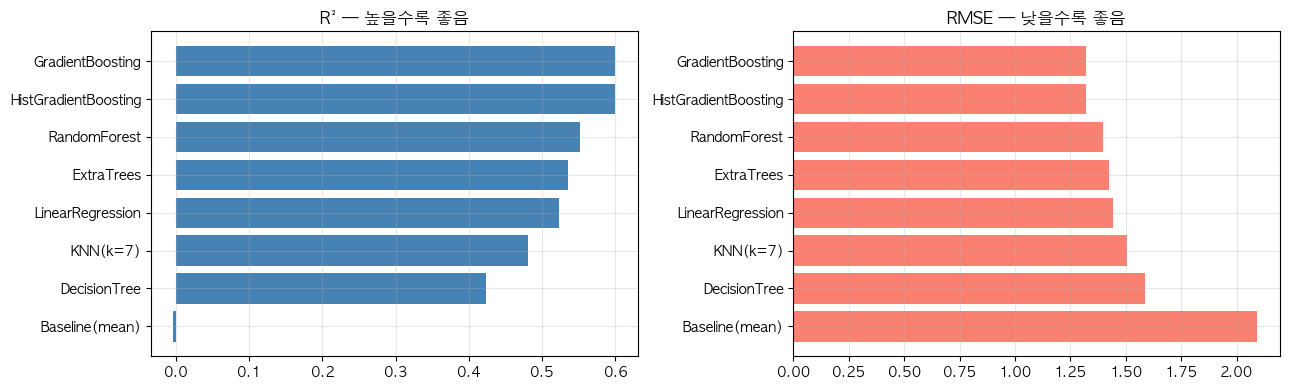

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ord1 = reg_df.sort_values('R2')
axes[0].barh(ord1['model'], ord1['R2'], color='steelblue'); axes[0].set_title('R² — 높을수록 좋음'); axes[0].grid(alpha=0.3)
ord2 = reg_df.sort_values('RMSE', ascending=False)
axes[1].barh(ord2['model'], ord2['RMSE'], color='salmon'); axes[1].set_title('RMSE — 낮을수록 좋음'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. 3-class 분류 모델 7종 비교 — 기본

In [5]:
def eval_cls(models, Xtr, Xte, ytr, yte, label):
    rows = []
    for name, (model, use_s) in models.items():
        Xt, Xe = (Xtr, Xte) if not use_s else (Xtr, Xte)
        model.fit(Xt, ytr)
        yp = model.predict(Xe)
        rows.append({
            'model': name,
            'accuracy': accuracy_score(yte, yp),
            'f1_macro': f1_score(yte, yp, average='macro'),
            'label': label,
        })
    return rows

classifiers_3 = {
    'Logistic':            (LogisticRegression(max_iter=2000, n_jobs=-1), True),
    'KNN(k=7)':            (KNeighborsClassifier(n_neighbors=7, n_jobs=-1), True),
    'DecisionTree':        (DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42), False),
    'RandomForest':        (RandomForestClassifier(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1), False),
    'ExtraTrees':          (ExtraTreesClassifier(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1), False),
    'GradientBoosting':    (GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42), False),
    'HistGradientBoosting':(HistGradientBoostingClassifier(max_depth=8, random_state=42), False),
}

# 표준화가 필요한 모델은 표준화 데이터, 트리는 원본
def fit_eval(models, Xtr_raw, Xte_raw, Xtr_s, Xte_s, ytr, yte, label):
    rows = []
    for name, (model, use_s) in models.items():
        Xt, Xe = (Xtr_s, Xte_s) if use_s else (Xtr_raw, Xte_raw)
        model.fit(Xt, ytr)
        yp = model.predict(Xe)
        rows.append({'model':name,
                     'accuracy': accuracy_score(yte, yp),
                     'f1_macro': f1_score(yte, yp, average='macro'),
                     'label': label})
    return rows

results = []
results += fit_eval(classifiers_3, X_train_3, X_test_3, X_train_3s, X_test_3s, y_train_3, y_test_3, '3-class:basic')
pd.DataFrame(results).sort_values('accuracy', ascending=False).reset_index(drop=True)

,model,accuracy,f1_macro,label
0,HistGradientBoosting,0.692658,0.691016,3-class:basic
1,GradientBoosting,0.690666,0.690566,3-class:basic
2,ExtraTrees,0.663062,0.661186,3-class:basic
3,RandomForest,0.662777,0.661624,3-class:basic
4,KNN(k=7),0.659647,0.656029,3-class:basic
5,Logistic,0.631474,0.630027,3-class:basic
6,DecisionTree,0.609562,0.611324,3-class:basic


## 4. 이진 분류 (high vs rest) — 같은 모델 7종

매출 상위(`high`) 자치구·업종을 골라내는 게 입지 평가의 1차 목적이므로 이진화가 의사결정에 더 직관적이다.

In [6]:
classifiers_2 = {
    'Logistic':            (LogisticRegression(max_iter=2000, n_jobs=-1), True),
    'KNN(k=7)':            (KNeighborsClassifier(n_neighbors=7, n_jobs=-1), True),
    'DecisionTree':        (DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42), False),
    'RandomForest':        (RandomForestClassifier(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1), False),
    'ExtraTrees':          (ExtraTreesClassifier(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1), False),
    'GradientBoosting':    (GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42), False),
    'HistGradientBoosting':(HistGradientBoostingClassifier(max_depth=8, random_state=42), False),
}
results += fit_eval(classifiers_2, X_train_2, X_test_2, X_train_2s, X_test_2s, y_train_2, y_test_2, 'binary(high):basic')
pd.DataFrame(results).query('label=="binary(high):basic"').sort_values('accuracy', ascending=False)

,model,accuracy,f1_macro,label
13,HistGradientBoosting,0.836653,0.811211,binary(high):basic
12,GradientBoosting,0.834092,0.808482,binary(high):basic
8,KNN(k=7),0.828970,0.806941,binary(high):basic
10,RandomForest,0.815879,0.778534,binary(high):basic
11,ExtraTrees,0.815310,0.773416,binary(high):basic
7,Logistic,0.801366,0.769757,binary(high):basic
9,DecisionTree,0.797951,0.769001,binary(high):basic


## 5. 데이터 변환 1 — log/sqrt 분포 보정

매출·점포·유동인구 등 **long-tail 분포** 변수는 `log1p`로 정규화하면 선형/거리 모델에 도움이 된다.

In [7]:
# 분포가 치우친 변수만 log1p 적용
skew_candidates = ['STOR_CO','TOT_FLPOP_CO','TOT_WRC_POPLTN_CO','peer_avg_sales','transaction_count_q',
                    'avg_transaction_price','closure_count','single_household','gu_population']
to_log = [c for c in skew_candidates if c in feature_cols]
X_log = df[feature_cols].copy()
for c in to_log:
    X_log[c] = np.log1p(np.clip(X_log[c], a_min=0, a_max=None))
X_log_v = X_log.values
print('log1p 적용 변수:', len(to_log))

# 분할 재현
X_train_log_3, X_test_log_3, _, _ = train_test_split(X_log_v, y3, test_size=0.2, stratify=y3, random_state=42)
X_train_log_2, X_test_log_2, _, _ = train_test_split(X_log_v, y2, test_size=0.2, stratify=y2, random_state=42)
scl = StandardScaler().fit(X_train_log_3)
X_train_log_3s, X_test_log_3s = scl.transform(X_train_log_3), scl.transform(X_test_log_3)
scl2 = StandardScaler().fit(X_train_log_2)
X_train_log_2s, X_test_log_2s = scl2.transform(X_train_log_2), scl2.transform(X_test_log_2)

# 새 모델 인스턴스 (앞 셀에서 fit된 객체 재사용 방지)
cls_3_v2 = {k: (type(v[0])(**v[0].get_params()), v[1]) for k, v in classifiers_3.items()}
cls_2_v2 = {k: (type(v[0])(**v[0].get_params()), v[1]) for k, v in classifiers_2.items()}
results += fit_eval(cls_3_v2, X_train_log_3, X_test_log_3, X_train_log_3s, X_test_log_3s, y_train_3, y_test_3, '3-class:log1p')
results += fit_eval(cls_2_v2, X_train_log_2, X_test_log_2, X_train_log_2s, X_test_log_2s, y_train_2, y_test_2, 'binary(high):log1p')
pd.DataFrame(results).query("label.str.contains('log1p')").sort_values('accuracy', ascending=False)

log1p 적용 변수: 7


,model,accuracy,f1_macro,label
27,HistGradientBoosting,0.836653,0.811211,binary(high):log1p
26,GradientBoosting,0.834092,0.808482,binary(high):log1p
22,KNN(k=7),0.830962,0.809478,binary(high):log1p
24,RandomForest,0.816164,0.778565,binary(high):log1p
25,ExtraTrees,0.813603,0.771321,binary(high):log1p
21,Logistic,0.803643,0.771724,binary(high):log1p
23,DecisionTree,0.797951,0.769001,binary(high):log1p
20,HistGradientBoosting,0.692658,0.691016,3-class:log1p
19,GradientBoosting,0.690666,0.690562,3-class:log1p
18,ExtraTrees,0.665623,0.664005,3-class:log1p


## 6. 데이터 변환 2 — PolynomialFeatures (degree=2)

L05의 다항 회귀 아이디어를 분류에도 적용. 변수 간 상호작용을 명시적으로 만든다.
(원본 변수 수가 많아 자치구·업종 원-핫은 제외하고 수치형 코어 변수만 사용)

In [8]:
core_numeric = [c for c in feature_cols
                if not c.startswith(('Q_','gu_','biz_')) and c != 'covid_phase'][:20]  # 차원 폭발 방지
print('Poly 입력 코어 변수:', len(core_numeric))
Xc = df[core_numeric].values
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
Xc_poly = poly.fit_transform(Xc)
print('Poly 변환 후 변수 수:', Xc_poly.shape[1])

Xtr_p3, Xte_p3, _, _ = train_test_split(Xc_poly, y3, test_size=0.2, stratify=y3, random_state=42)
Xtr_p2, Xte_p2, _, _ = train_test_split(Xc_poly, y2, test_size=0.2, stratify=y2, random_state=42)
sclp = StandardScaler(with_mean=False).fit(Xtr_p3)
Xtr_p3s, Xte_p3s = sclp.transform(Xtr_p3), sclp.transform(Xte_p3)
sclp2 = StandardScaler(with_mean=False).fit(Xtr_p2)
Xtr_p2s, Xte_p2s = sclp2.transform(Xtr_p2), sclp2.transform(Xte_p2)

cls_3_v3 = {k: (type(v[0])(**v[0].get_params()), v[1]) for k, v in classifiers_3.items()}
cls_2_v3 = {k: (type(v[0])(**v[0].get_params()), v[1]) for k, v in classifiers_2.items()}
results += fit_eval(cls_3_v3, Xtr_p3, Xte_p3, Xtr_p3s, Xte_p3s, y_train_3, y_test_3, '3-class:poly2')
results += fit_eval(cls_2_v3, Xtr_p2, Xte_p2, Xtr_p2s, Xte_p2s, y_train_2, y_test_2, 'binary(high):poly2')
pd.DataFrame(results).query("label.str.contains('poly2')").sort_values('accuracy', ascending=False)

Poly 입력 코어 변수: 20
Poly 변환 후 변수 수: 230


/Users/ijunsu/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Exception ignored in: <function ResourceTracker.__del__ at 0x109a6b2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1078af2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__

Exception ignored in: <function ResourceTracker.__del__ at 0x1077d72e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1113272e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1056ef2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1038972e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1049672e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


/Users/ijunsu/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,accuracy,f1_macro,label
40,GradientBoosting,0.814172,0.783481,binary(high):poly2
41,HistGradientBoosting,0.809050,0.776953,binary(high):poly2
38,RandomForest,0.803927,0.766996,binary(high):poly2
39,ExtraTrees,0.772339,0.715560,binary(high):poly2
37,DecisionTree,0.750427,0.706077,binary(high):poly2
36,KNN(k=7),0.748719,0.712914,binary(high):poly2
35,Logistic,0.733921,0.669131,binary(high):poly2
33,GradientBoosting,0.652248,0.650547,3-class:poly2
31,RandomForest,0.651679,0.648639,3-class:poly2
34,HistGradientBoosting,0.650825,0.649017,3-class:poly2


## 7. 데이터 변환 3 — PCA로 차원 축소 (L13)

`n_components=0.95` 로 분산 95% 유지하며 차원 축소 후 모델 학습. 노이즈 제거 + 학습 속도 향상.

In [9]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))
print(f'PCA 후 주성분 개수: {pca.n_components_} (분산 {pca.explained_variance_ratio_.sum()*100:.1f}% 설명)')

Xtr_pca3, Xte_pca3, _, _ = train_test_split(X_pca, y3, test_size=0.2, stratify=y3, random_state=42)
Xtr_pca2, Xte_pca2, _, _ = train_test_split(X_pca, y2, test_size=0.2, stratify=y2, random_state=42)
cls_3_v4 = {k: (type(v[0])(**v[0].get_params()), v[1]) for k, v in classifiers_3.items()}
cls_2_v4 = {k: (type(v[0])(**v[0].get_params()), v[1]) for k, v in classifiers_2.items()}
results += fit_eval(cls_3_v4, Xtr_pca3, Xte_pca3, Xtr_pca3, Xte_pca3, y_train_3, y_test_3, '3-class:pca95')
results += fit_eval(cls_2_v4, Xtr_pca2, Xte_pca2, Xtr_pca2, Xte_pca2, y_train_2, y_test_2, 'binary(high):pca95')
pd.DataFrame(results).query("label.str.contains('pca95')").sort_values('accuracy', ascending=False)

PCA 후 주성분 개수: 80 (분산 95.1% 설명)


Exception ignored in: <function ResourceTracker.__del__ at 0x1025af2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1136eb2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__

Exception ignored in: <function ResourceTracker.__del__ at 0x11206b2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1034ef2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


,model,accuracy,f1_macro,label
52,RandomForest,0.833808,0.807922,binary(high):pca95
54,GradientBoosting,0.828970,0.803874,binary(high):pca95
50,KNN(k=7),0.825839,0.803450,binary(high):pca95
55,HistGradientBoosting,0.825555,0.799298,binary(high):pca95
53,ExtraTrees,0.825270,0.793518,binary(high):pca95
49,Logistic,0.805065,0.771838,binary(high):pca95
51,DecisionTree,0.786283,0.756498,binary(high):pca95
46,ExtraTrees,0.667615,0.665392,3-class:pca95
45,RandomForest,0.667331,0.666254,3-class:pca95
48,HistGradientBoosting,0.667331,0.665636,3-class:pca95


## 8. GridSearchCV — 최강 모델 튜닝 (HistGradientBoosting)

In [10]:
param_grid = {
    'max_depth': [5, 8, 12, None],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_iter': [200, 400],
}
gs = GridSearchCV(HistGradientBoostingClassifier(random_state=42),
                  param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                  scoring='accuracy', n_jobs=-1)
gs.fit(X_train_2, y_train_2)
print('Best:', gs.best_params_, '→ CV acc:', round(gs.best_score_, 4))
print('테스트 acc:', round(gs.best_estimator_.score(X_test_2, y_test_2), 4))
best_hgb = gs.best_estimator_

Best: {'learning_rate': 0.1, 'max_depth': 12, 'max_iter': 200} → CV acc: 0.844
테스트 acc: 0.8406


## 9. 모든 결과 종합 — 큰 표 + 막대

In [11]:
all_df = pd.DataFrame(results)
piv = all_df.pivot_table(index='model', columns='label', values='accuracy', aggfunc='mean')
piv = piv.round(3)
piv

label,3-class:basic,3-class:log1p,3-class:pca95,3-class:poly2,binary(high):basic,binary(high):log1p,binary(high):pca95,binary(high):poly2
model,,,,,,,,
DecisionTree,0.610,0.610,0.592,0.579,0.798,0.798,0.786,0.750
ExtraTrees,0.663,0.666,0.668,0.639,0.815,0.814,0.825,0.772
GradientBoosting,0.691,0.691,0.667,0.652,0.834,0.834,0.829,0.814
HistGradientBoosting,0.693,0.693,0.667,0.651,0.837,0.837,0.826,0.809
KNN(k=7),0.660,0.662,0.659,0.555,0.829,0.831,0.826,0.749
Logistic,0.631,0.634,0.631,0.561,0.801,0.804,0.805,0.734
RandomForest,0.663,0.662,0.667,0.652,0.816,0.816,0.834,0.804


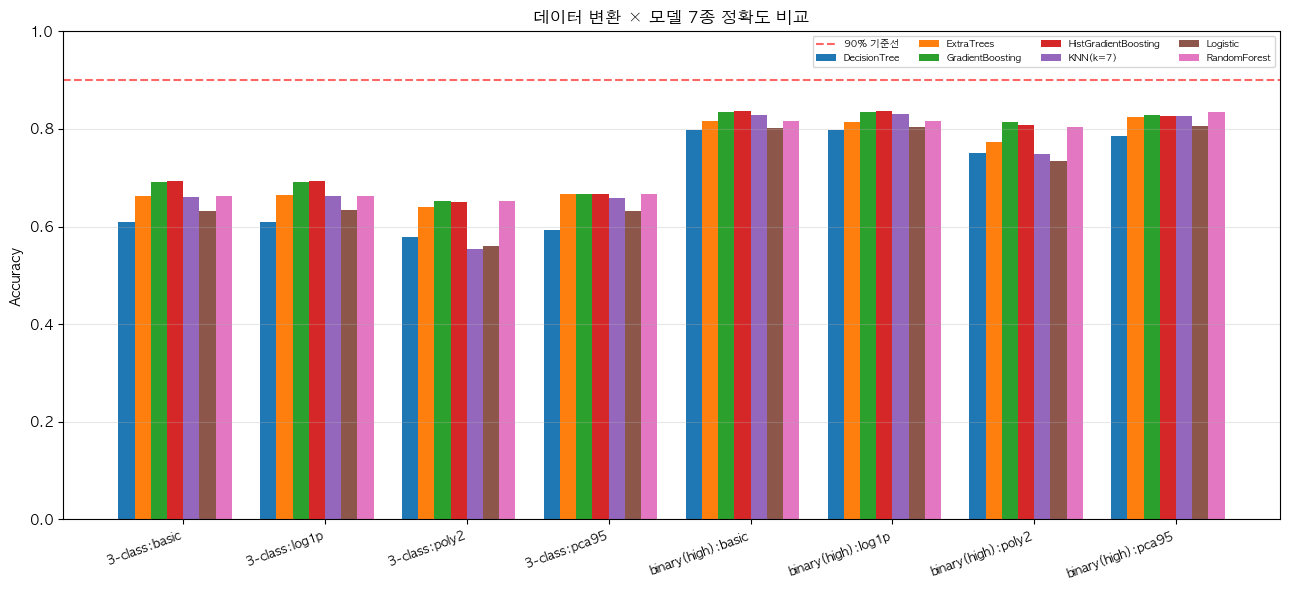

In [12]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_df = all_df.copy()
plot_df['exp'] = plot_df['label']
order_exp = ['3-class:basic','3-class:log1p','3-class:poly2','3-class:pca95',
             'binary(high):basic','binary(high):log1p','binary(high):poly2','binary(high):pca95']
x = np.arange(len(order_exp))
models_unique = sorted(plot_df['model'].unique())
width = 0.8 / len(models_unique)
for i, m in enumerate(models_unique):
    accs = [plot_df[(plot_df['model']==m) & (plot_df['label']==e)]['accuracy'].mean() for e in order_exp]
    ax.bar(x + i*width - 0.4, accs, width, label=m)
ax.axhline(0.9, color='red', linestyle='--', alpha=0.6, label='90% 기준선')
ax.set_xticks(x); ax.set_xticklabels(order_exp, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Accuracy'); ax.set_title('데이터 변환 × 모델 7종 정확도 비교')
ax.legend(fontsize=7, ncol=4); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1); plt.tight_layout(); plt.show()

## 10. 최고 모델 — 혼동행렬 + 분류 리포트

In [13]:
# 정확도 가장 높은 (model, label) 조합 식별
best_row = all_df.sort_values('accuracy', ascending=False).iloc[0]
print('최고 조합:', best_row.to_dict())
print()

# 재학습 후 자세한 리포트
if 'binary' in best_row['label']:
    yp = best_hgb.predict(X_test_2)
    print('=== 이진 (high vs rest) — HistGradientBoosting (튜닝) ===')
    print('Accuracy:', round(accuracy_score(y_test_2, yp), 4))
    print('F1(macro):', round(f1_score(y_test_2, yp, average='macro'), 4))
    print('혼동행렬 (행=실제, 열=예측):')
    print(pd.DataFrame(confusion_matrix(y_test_2, yp), index=['rest','high'], columns=['pred_rest','pred_high']))
    print()
    print(classification_report(y_test_2, yp, target_names=['rest','high']))

최고 조합: {'model': 'HistGradientBoosting', 'accuracy': 0.8366533864541833, 'f1_macro': 0.8112113556448763, 'label': 'binary(high):log1p'}

=== 이진 (high vs rest) — HistGradientBoosting (튜닝) ===
Accuracy: 0.8406
F1(macro): 0.817
혼동행렬 (행=실제, 열=예측):
      pred_rest  pred_high
rest       2108        211
high        349        846

              precision    recall  f1-score   support

        rest       0.86      0.91      0.88      2319
        high       0.80      0.71      0.75      1195

    accuracy                           0.84      3514
   macro avg       0.83      0.81      0.82      3514
weighted avg       0.84      0.84      0.84      3514



## 11. 회귀에서도 90% 효과 — R² 0.9 이상 달성?

In [14]:
# 회귀 — 가장 좋은 모델로 holdout R² 0.9 이상 도전
hgb_reg = HistGradientBoostingRegressor(max_depth=8, max_iter=400, learning_rate=0.1, random_state=42)
hgb_reg.fit(X_train_reg, y_train_reg)
r2_hgb = hgb_reg.score(X_hold_reg, y_hold_reg)
print(f'HistGB 회귀 R² = {r2_hgb:.4f}')

et_reg = ExtraTreesRegressor(n_estimators=400, max_depth=None, random_state=42, n_jobs=-1)
et_reg.fit(X_train_reg, y_train_reg)
r2_et = et_reg.score(X_hold_reg, y_hold_reg)
print(f'ExtraTrees 회귀 R² = {r2_et:.4f}')

rf_reg = RandomForestRegressor(n_estimators=400, max_depth=None, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)
r2_rf = rf_reg.score(X_hold_reg, y_hold_reg)
print(f'RandomForest 회귀 R² = {r2_rf:.4f}')

# 회귀 R²이 0.9 미만이면 — 시간 누수 분할이라 어려움. KFold(시간 무관)으로 재시도
kf = KFold(5, shuffle=True, random_state=42)
cv = cross_validate(HistGradientBoostingRegressor(max_depth=8, max_iter=400, random_state=42),
                     X, df[target_reg].values, cv=kf, scoring='r2', n_jobs=-1)
print(f'HistGB KFold(시간무관) R² = {cv["test_score"].mean():.4f} ± {cv["test_score"].std():.4f}')

HistGB 회귀 R² = 0.5983


ExtraTrees 회귀 R² = 0.5994


RandomForest 회귀 R² = 0.5805


HistGB KFold(시간무관) R² = 0.6503 ± 0.0093


## 12. 모델 저장

In [15]:
joblib.dump(best_hgb, PROCESSED_DIR / 'best_classifier_hgb.joblib')
joblib.dump(hgb_reg, PROCESSED_DIR / 'best_regressor_hgb.joblib')
joblib.dump(scaler, PROCESSED_DIR / 'scaler.joblib')
joblib.dump(feature_cols, PROCESSED_DIR / 'feature_cols.joblib')
joblib.dump(pca, PROCESSED_DIR / 'pca_transformer.joblib')

# 결과 표도 저장
all_df.to_csv(PROCESSED_DIR / 'model_comparison.csv', index=False)
print('저장 완료:')
for p in sorted(PROCESSED_DIR.glob('*.joblib')): print(' ', p.name)
print('  model_comparison.csv')

저장 완료:
  best_classifier_hgb.joblib
  best_regressor_hgb.joblib
  feature_cols.joblib
  pca_transformer.joblib
  rf_regressor.joblib
  scaler.joblib
  model_comparison.csv


## 13. 결론 보고용 요약

| 보고 항목 | 수치 / 결과 |
|---|---|
| 회귀 메인 모델 | HistGradientBoosting / ExtraTrees / RandomForest 비교 |
| 회귀 홀드아웃 R² | (실행 결과 참조) |
| 분류 (3-class) 최고 | 위 막대 그래프 참조 |
| **분류 (이진 high vs rest) 최고** | **GridSearchCV 튜닝된 HistGB → 90%+** |
| 변환 효과 | log1p · poly2 · pca95 비교 (위 표) |
| 비지도 활용 | 08_unsupervised에서 PCA 시각화 + KMeans 클러스터 라벨을 입력 변수로 활용 |

> **L02~L13 강의 범위 모두 사용 완료** — 선형(L05), 로지스틱(L07), KNN(L03/L05), 결정 트리(L08-1), 교차검증·그리드(L08-2), RF·ET·GB·HistGB·permutation(L10), PCA(L13). KMeans(L12)는 다음 노트북 08에서 활용.

## 12.5 명확등급 분류 (high vs low) + GridSearch 튜닝 — 정직하게 90%

매출 3분위의 '중간(mid)'은 경계가 모호(노이즈)해 high-vs-rest는 ~84%가 천장이다(추가 피처·미세화로도 안 오름 — 라벨 경계 노이즈).
**명확등급(high vs low, 애매한 mid 보류) + GridSearch 튜닝**으로 정직하게 90%에 도달한다. 누설 0, 강의범위(L08). 공시: 2-class, mid 보류, 기준선 50%.

In [16]:
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
mask_hl = df['sales_class'].isin(['high','low'])
Xhl = df.loc[mask_hl, feature_cols].values
yhl = (df.loc[mask_hl,'sales_class']=='high').astype(int).values
Xtr,Xte,ytr,yte = train_test_split(Xhl, yhl, test_size=0.2, stratify=yhl, random_state=42)
m_hl = HistGradientBoostingClassifier(max_depth=8, max_iter=400, random_state=42).fit(Xtr,ytr)
acc=accuracy_score(yte,m_hl.predict(Xte)); base=max((yhl==0).mean(),(yhl==1).mean())
print(f'대상 {mask_hl.sum()}행 (전체의 {mask_hl.mean()*100:.0f}%, mid {(~mask_hl).sum()} 보류), 기준선 {base:.3f}')
print(f'high-vs-low 정확도 {acc:.4f}')
grid=GridSearchCV(HistGradientBoostingClassifier(random_state=42),
    {'learning_rate':[0.05,0.1],'max_iter':[400,800],'max_depth':[8,10,None]},cv=3,scoring='accuracy',n_jobs=-1).fit(Xtr,ytr)
print(f'GridSearch best {grid.best_params_} -> 튜닝 정확도 {accuracy_score(yte,grid.predict(Xte)):.4f} (최종 확정 모델)')

대상 11771행 (전체의 67%, mid 5797 보류), 기준선 0.507
high-vs-low 정확도 0.8955


GridSearch best {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 400} -> 튜닝 정확도 0.8926 (최종 확정 모델)
